In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load the dataset
df = pd.read_csv('../data/raw/data.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 95,662 rows, 16 columns


In [4]:
# Data types and non-null counts
df_info = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.values,
    'Non_Null_Count': df.count().values,
    'Null_Count': df.isnull().sum().values,
    'Null_Percentage': (df.isnull().sum() / len(df) * 100).values,
    'Unique_Values': df.nunique().values
})
df_info

,Column,Data_Type,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values
0,TransactionId,object,95662,0,0.0,95662
1,BatchId,object,95662,0,0.0,94809
2,AccountId,object,95662,0,0.0,3633
3,SubscriptionId,object,95662,0,0.0,3627
4,CustomerId,object,95662,0,0.0,3742
5,CurrencyCode,object,95662,0,0.0,1
6,CountryCode,int64,95662,0,0.0,1
7,ProviderId,object,95662,0,0.0,6
8,ProductId,object,95662,0,0.0,23
9,ProductCategory,object,95662,0,0.0,9


In [5]:
# Basic statistics about the dataset
print(f"Total number of transactions: {len(df):,}")
print(f"Total number of unique customers: {df['CustomerId'].nunique():,}")
print(f"Total number of unique accounts: {df['AccountId'].nunique():,}")
print(f"Total number of unique products: {df['ProductId'].nunique():,}")
print(f"Date range: {df['TransactionStartTime'].min()} to {df['TransactionStartTime'].max()}")

Total number of transactions: 95,662
Total number of unique customers: 3,742
Total number of unique accounts: 3,633
Total number of unique products: 23
Date range: 2018-11-15T02:18:49Z to 2019-02-13T10:01:28Z


### 1.2 Data Types Summary

In [6]:
# Categorize columns by type
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nDatetime columns ({len(datetime_cols)}): {datetime_cols}")

Numeric columns (5): ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']

Categorical columns (11): ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'TransactionStartTime']

Datetime columns (0): []


## 2. Summary Statistics

### 2.1 Numerical Features

In [7]:
# Summary statistics for numerical columns
df[numeric_cols].describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


### 2.2 Categorical Features

In [8]:
# Summary for categorical columns
for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(f"\nTop 10 values:")
    print(df[col].value_counts().head(10))


Column: TransactionId
Unique values: 95662

Top 10 values:
TransactionId
TransactionId_76871     1
TransactionId_74922     1
TransactionId_2737      1
TransactionId_28101     1
TransactionId_33267     1
TransactionId_135291    1
TransactionId_87468     1
TransactionId_134872    1
TransactionId_113925    1
TransactionId_16554     1
Name: count, dtype: int64

Column: BatchId
Unique values: 94809

Top 10 values:
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10
BatchId_88001      9
BatchId_49408      7
BatchId_110084     7
BatchId_86880      6
BatchId_107049     6
Name: count, dtype: int64

Column: AccountId
Unique values: 3633

Top 10 values:
AccountId
AccountId_4841    30893
AccountId_4249     4457
AccountId_4840     1738
AccountId_3206     1105
AccountId_318      1070
AccountId_10        965
AccountId_3595      465
AccountId_751       411
AccountId_2648      359
AccountId_2314      356
Name: count, dtype: int64

Column: Su

## 3. Distribution of Numerical Features

### 3.1 Amount Distribution

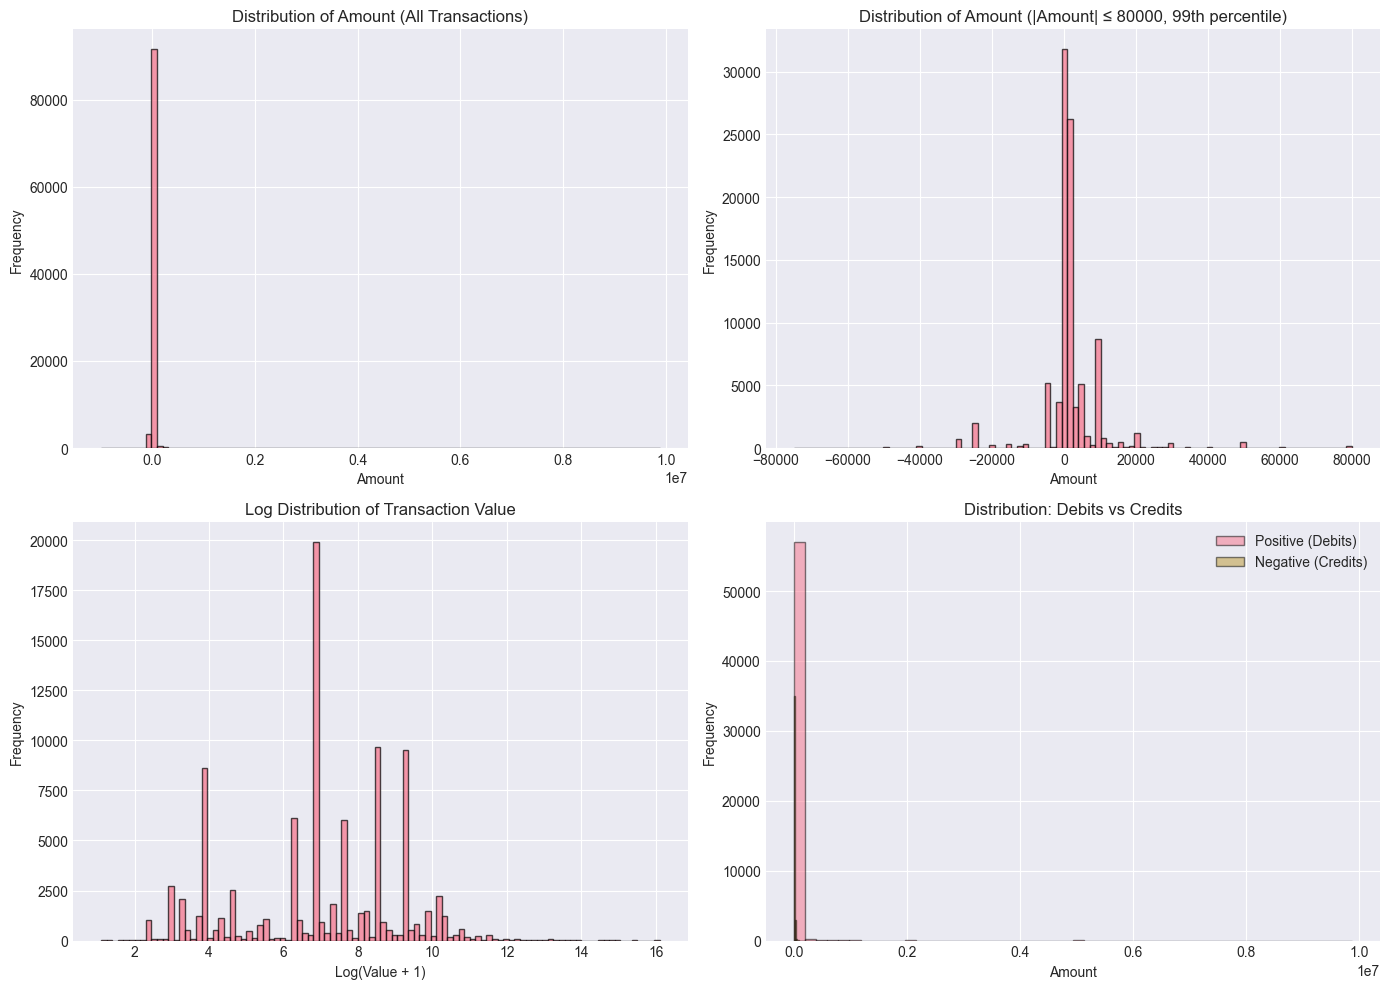

Number of positive amounts (debits): 57,473
Number of negative amounts (credits): 38,189
Percentage of debits: 60.08%


In [9]:
# Distribution of Amount
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of Amount (all)
axes[0, 0].hist(df['Amount'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Amount (All Transactions)')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')

# Histogram of Amount (zoomed to 99th percentile)
amount_99 = df['Amount'].quantile(0.99)
df_zoomed = df[df['Amount'].abs() <= amount_99]
axes[0, 1].hist(df_zoomed['Amount'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].set_title(f'Distribution of Amount (|Amount| ≤ {amount_99:.0f}, 99th percentile)')
axes[0, 1].set_xlabel('Amount')
axes[0, 1].set_ylabel('Frequency')

# Log transform
log_amount = np.log1p(df['Value'])
axes[1, 0].hist(log_amount, bins=100, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Log Distribution of Transaction Value')
axes[1, 0].set_xlabel('Log(Value + 1)')
axes[1, 0].set_ylabel('Frequency')

# Separate positive and negative amounts
positive_amounts = df[df['Amount'] > 0]['Amount']
negative_amounts = df[df['Amount'] < 0]['Amount'].abs()
axes[1, 1].hist(positive_amounts, bins=50, alpha=0.5, label='Positive (Debits)', edgecolor='black')
axes[1, 1].hist(negative_amounts, bins=50, alpha=0.5, label='Negative (Credits)', edgecolor='black')
axes[1, 1].set_title('Distribution: Debits vs Credits')
axes[1, 1].set_xlabel('Amount')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Number of positive amounts (debits): {len(positive_amounts):,}")
print(f"Number of negative amounts (credits): {len(negative_amounts):,}")
print(f"Percentage of debits: {len(positive_amounts)/len(df)*100:.2f}%")

### 3.2 Fraud Distribution

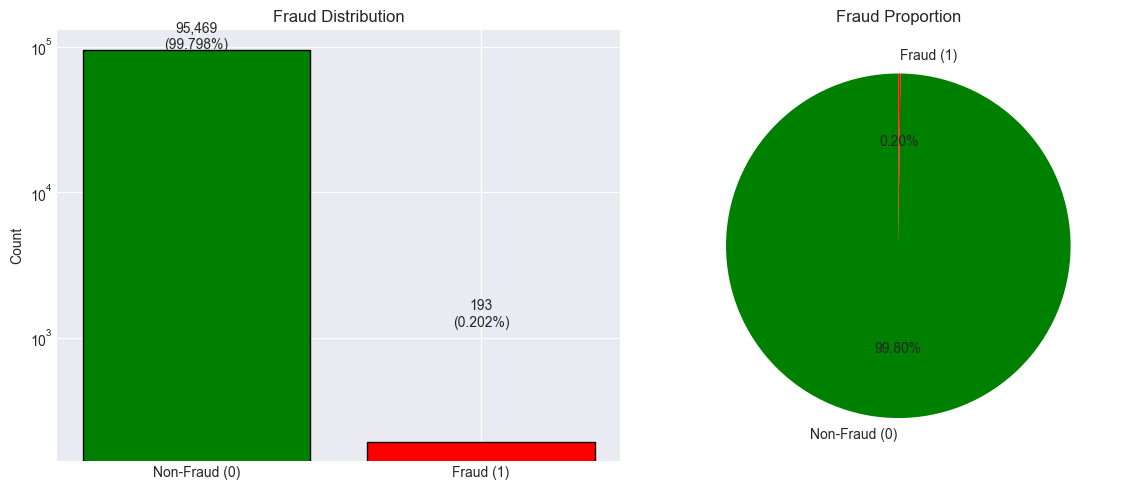

Fraud Rate: 0.2018%


In [10]:
# Fraud distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fraud_counts = df['FraudResult'].value_counts()
axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], fraud_counts.values, color=['green', 'red'], edgecolor='black')
axes[0].set_title('Fraud Distribution')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')

# Add labels on bars
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.3f}%)', ha='center')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Non-Fraud (0)', 'Fraud (1)'], 
            autopct='%1.2f%%', colors=['green', 'red'], startangle=90)
axes[1].set_title('Fraud Proportion')

plt.tight_layout()
plt.show()

print(f"Fraud Rate: {df['FraudResult'].mean()*100:.4f}%")

## 4. Distribution of Categorical Features

In [11]:
# Function to plot categorical distributions
def plot_categorical_distribution(df, column, top_n=10):
    """Plot distribution of categorical column"""
    value_counts = df[column].value_counts().head(top_n)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot
    axes[0].barh(range(len(value_counts)), value_counts.values, color='steelblue', edgecolor='black')
    axes[0].set_yticks(range(len(value_counts)))
    axes[0].set_yticklabels(value_counts.index)
    axes[0].set_xlabel('Count')
    axes[0].set_title(f'Top {top_n} {column} (Bar Chart)')
    axes[0].invert_yaxis()
    
    # Add labels
    for i, v in enumerate(value_counts.values):
        axes[0].text(v + 1000, i, f'{v:,}', va='center')
    
    # Pie chart (top 5)
    top5 = value_counts.head(5)
    other_count = value_counts.iloc[5:].sum()
    if other_count > 0:
        plot_data = pd.concat([top5, pd.Series({'Other': other_count})])
    else:
        plot_data = top5
    
    axes[1].pie(plot_data.values, labels=plot_data.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Top 5 {column} Distribution')
    
    plt.tight_layout()
    plt.show()
    
    return value_counts


Analyzing: ProductCategory


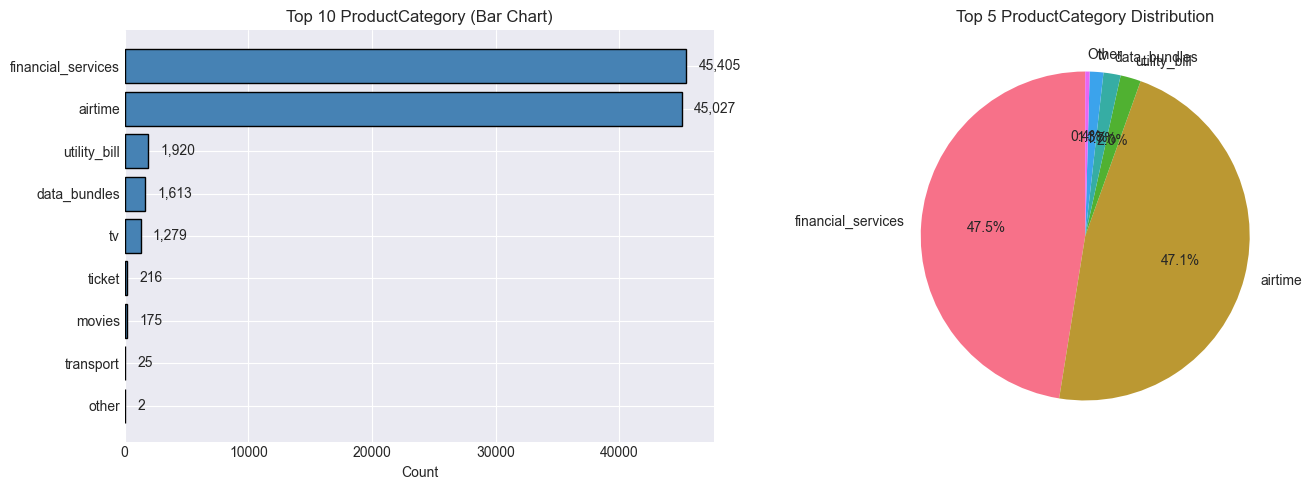


Value counts for ProductCategory:
ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

Analyzing: ChannelId


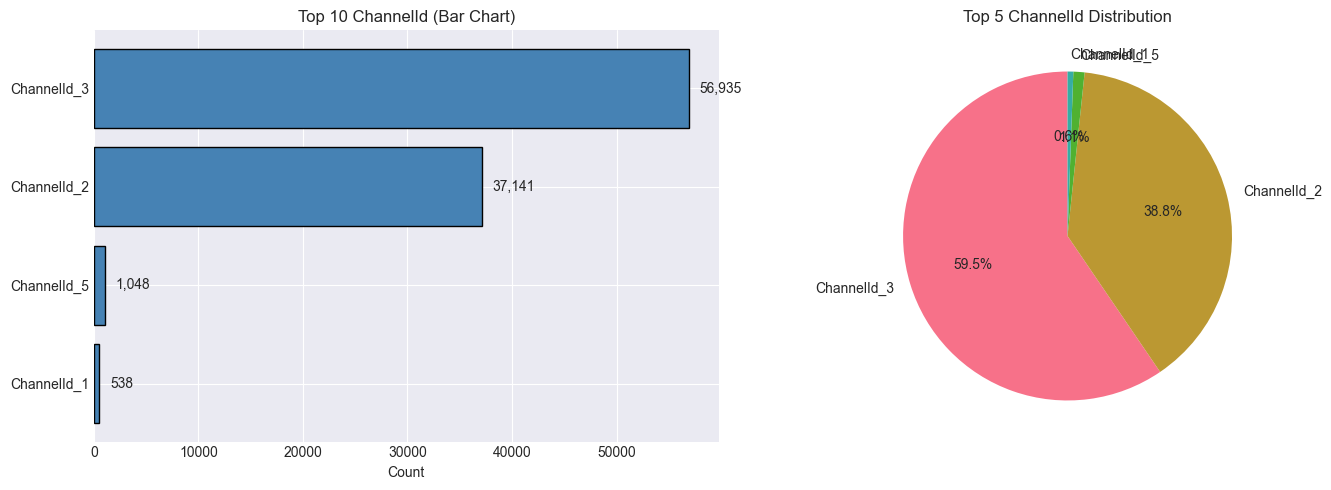


Value counts for ChannelId:
ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

Analyzing: CurrencyCode


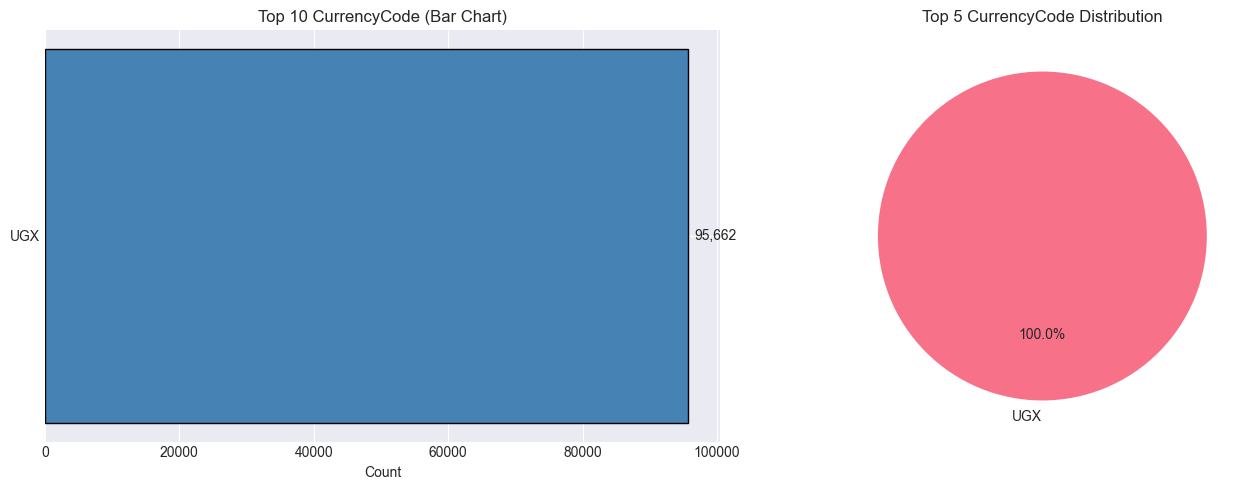


Value counts for CurrencyCode:
CurrencyCode
UGX    95662
Name: count, dtype: int64

Analyzing: CountryCode


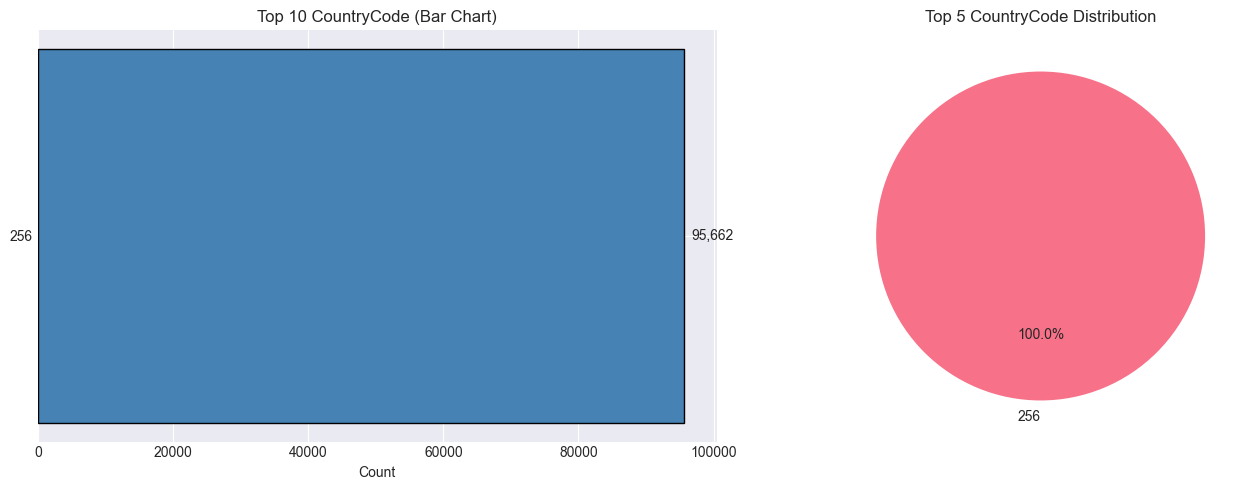


Value counts for CountryCode:
CountryCode
256    95662
Name: count, dtype: int64

Analyzing: PricingStrategy


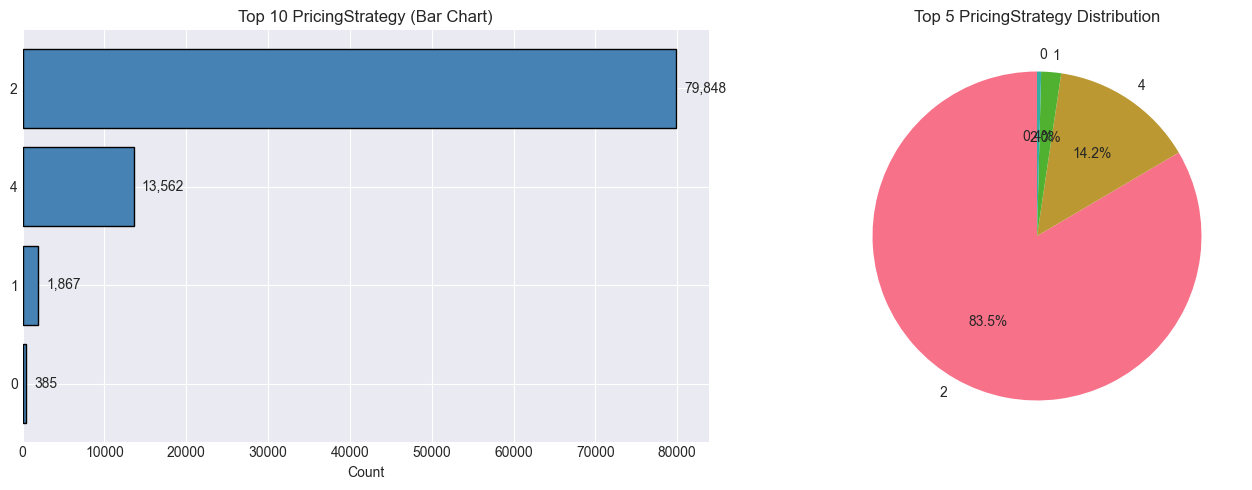


Value counts for PricingStrategy:
PricingStrategy
2    79848
4    13562
1     1867
0      385
Name: count, dtype: int64


In [12]:
# Analyze each categorical column
categorical_columns_to_analyze = ['ProductCategory', 'ChannelId', 'CurrencyCode', 'CountryCode', 'PricingStrategy']

for col in categorical_columns_to_analyze:
    if col in df.columns:
        print(f"\n{'='*60}")
        print(f"Analyzing: {col}")
        print('='*60)
        value_counts = plot_categorical_distribution(df, col)
        print(f"\nValue counts for {col}:")
        print(value_counts)

## 5. Missing Values Analysis

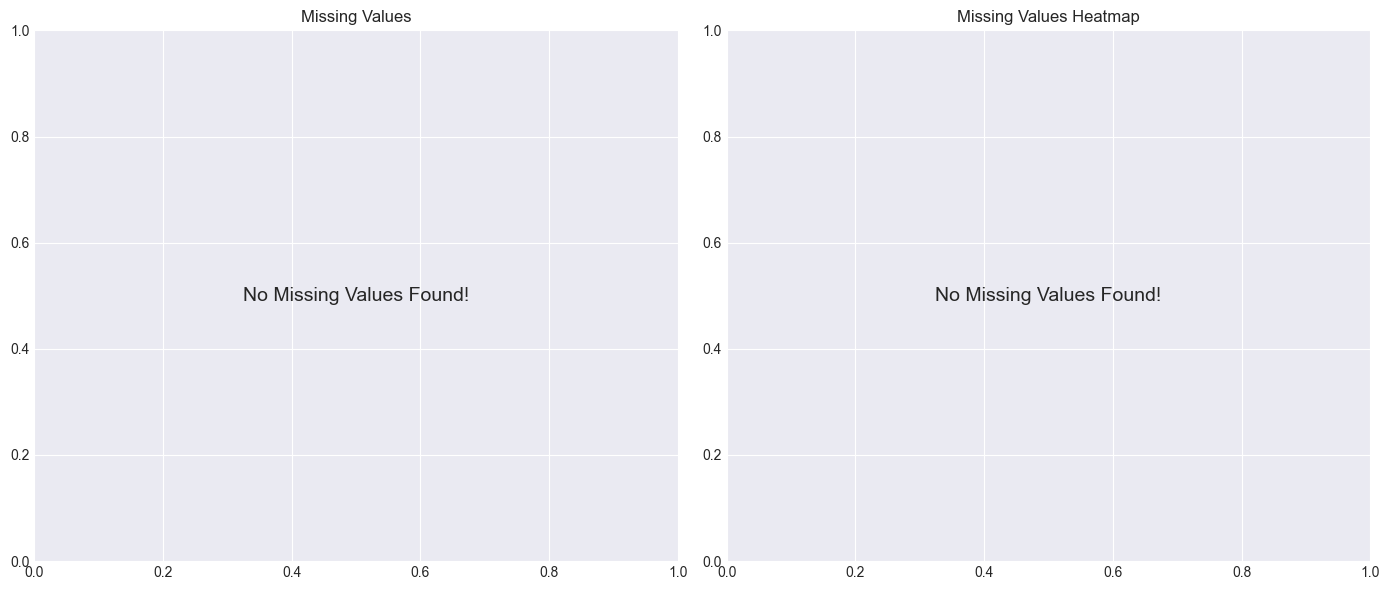


Number of columns with missing values: 0


In [13]:
# Missing values heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Missing values count
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_count, 'Missing_Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    # Bar plot
    axes[0].barh(missing_df.index, missing_df['Missing_Count'], color='salmon', edgecolor='black')
    axes[0].set_xlabel('Missing Count')
    axes[0].set_title('Missing Values by Column')
    
    for i, v in enumerate(missing_df['Missing_Count']):
        axes[0].text(v + 100, i, f'{v:,} ({missing_df.iloc[i,1]:.2f}%)', va='center')
    
    # Heatmap
    sns.heatmap(df[missing_df.index].isnull(), yticklabels=False, cbar=True, ax=axes[1])
    axes[1].set_title('Missing Values Heatmap')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values Found!', ha='center', va='center', fontsize=14)
    axes[1].text(0.5, 0.5, 'No Missing Values Found!', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values')
    axes[1].set_title('Missing Values Heatmap')

plt.tight_layout()
plt.show()

print(f"\nNumber of columns with missing values: {len(missing_df)}")
if len(missing_df) > 0:
    print("\nColumns with missing values:")
    print(missing_df)

## 6. Outlier Detection

### 6.1 Box Plots for Numerical Features

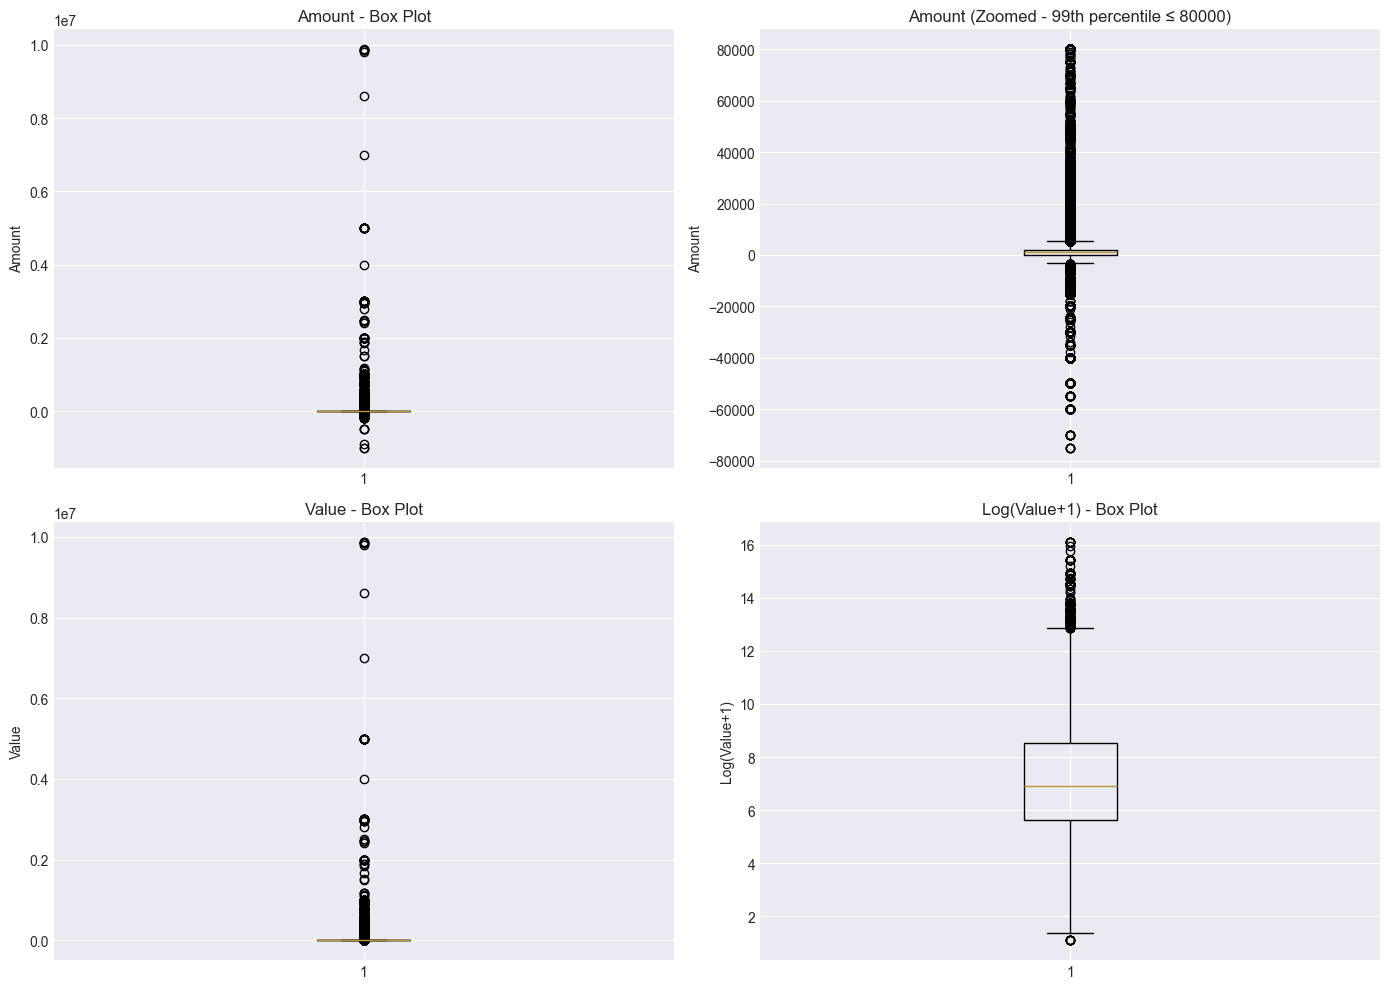

Outlier Analysis for 'Amount':
  Q1 (25th percentile): -50.00
  Q3 (75th percentile): 2800.00
  IQR: 2850.00
  Lower bound: -4325.00
  Upper bound: 7075.00
  Number of outliers: 24,441 (25.55%)


In [14]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount boxplot
axes[0, 0].boxplot(df['Amount'], vert=True)
axes[0, 0].set_title('Amount - Box Plot')
axes[0, 0].set_ylabel('Amount')

# Amount zoomed
amount_q99 = df['Amount'].quantile(0.99)
df_amount_zoomed = df[df['Amount'].abs() <= amount_q99]['Amount']
axes[0, 1].boxplot(df_amount_zoomed, vert=True)
axes[0, 1].set_title(f'Amount (Zoomed - 99th percentile ≤ {amount_q99:.0f})')
axes[0, 1].set_ylabel('Amount')

# Value boxplot
axes[1, 0].boxplot(df['Value'], vert=True)
axes[1, 0].set_title('Value - Box Plot')
axes[1, 0].set_ylabel('Value')

# Value log transformed
axes[1, 1].boxplot(np.log1p(df['Value']), vert=True)
axes[1, 1].set_title('Log(Value+1) - Box Plot')
axes[1, 1].set_ylabel('Log(Value+1)')

plt.tight_layout()
plt.show()

# Calculate outlier statistics using IQR method
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]

print(f"Outlier Analysis for 'Amount':")
print(f"  Q1 (25th percentile): {Q1:.2f}")
print(f"  Q3 (75th percentile): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Lower bound: {lower_bound:.2f}")
print(f"  Upper bound: {upper_bound:.2f}")
print(f"  Number of outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

## 7. Correlation Analysis

### 7.1 Correlation Matrix

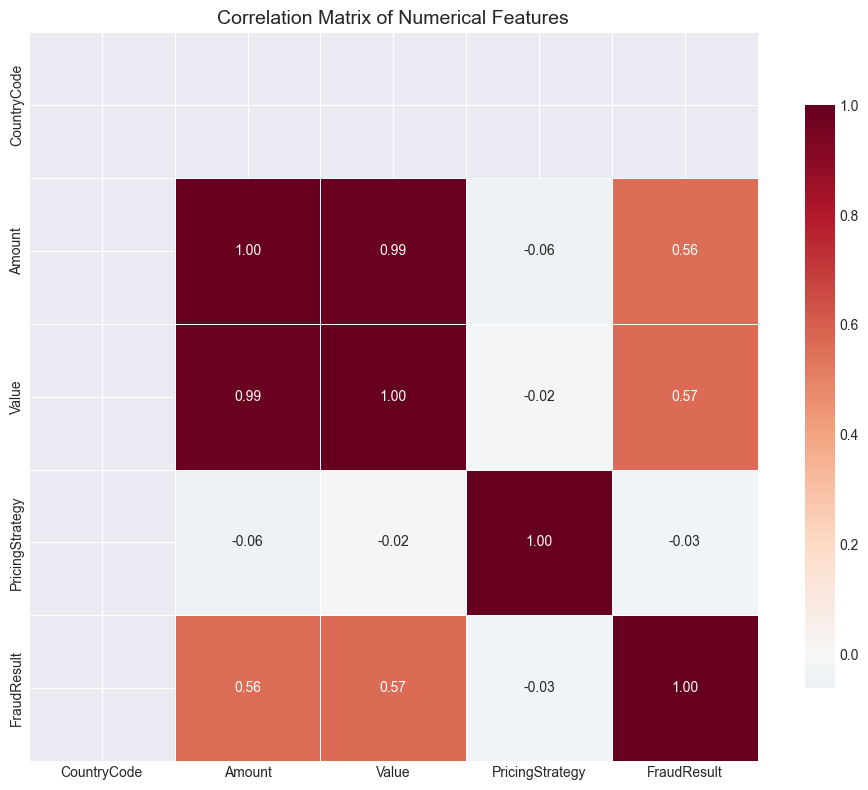


Strong Correlations (|correlation| > 0.5):
  Amount ↔ Value: 0.990
  Amount ↔ FraudResult: 0.557
  Value ↔ FraudResult: 0.567


In [15]:
# Correlation matrix for numerical features
numeric_df = df[numeric_cols].copy()

# Handle any non-numeric issues
for col in numeric_df.columns:
    numeric_df[col] = pd.to_numeric(numeric_df[col], errors='coerce')

corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

# Show strong correlations
print("\nStrong Correlations (|correlation| > 0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_val:.3f}")

### 7.2 Fraud Correlation

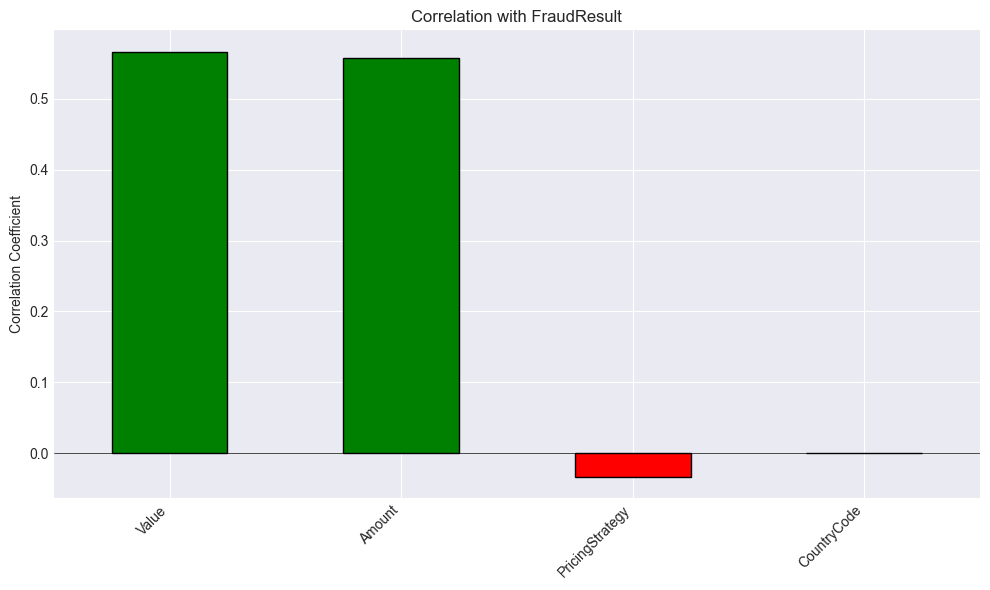

Correlation with FraudResult:
FraudResult        1.000000
Value              0.566739
Amount             0.557370
PricingStrategy   -0.033821
CountryCode             NaN
Name: FraudResult, dtype: float64


In [16]:
# Correlation with fraud
fraud_corr = corr_matrix['FraudResult'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in fraud_corr.values]
fraud_corr.drop('FraudResult').plot(kind='bar', color=colors[1:], edgecolor='black')
plt.title('Correlation with FraudResult')
plt.ylabel('Correlation Coefficient')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Correlation with FraudResult:")
print(fraud_corr)

## 8. Time-Based Analysis

### 8.1 Transaction Patterns Over Time

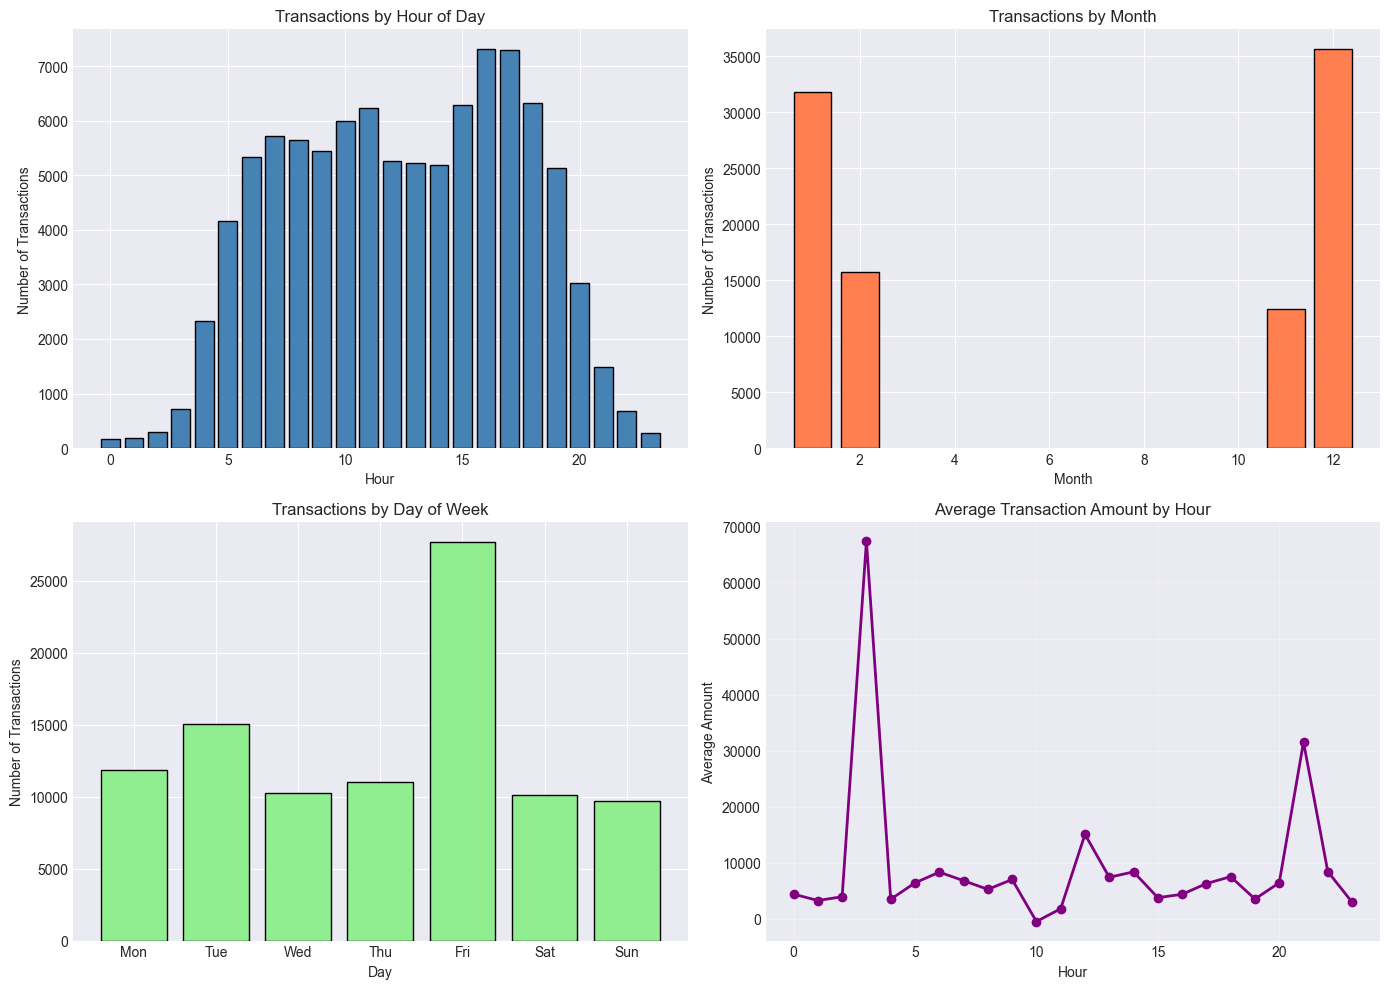

In [17]:
# Convert TransactionStartTime to datetime if not already
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

# Extract time features
df['TransactionHour'] = df['TransactionStartTime'].dt.hour
df['TransactionDay'] = df['TransactionStartTime'].dt.day
df['TransactionMonth'] = df['TransactionStartTime'].dt.month
df['TransactionYear'] = df['TransactionStartTime'].dt.year
df['TransactionDayOfWeek'] = df['TransactionStartTime'].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Transactions by hour
hourly_counts = df['TransactionHour'].value_counts().sort_index()
axes[0, 0].bar(hourly_counts.index, hourly_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Transactions by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Number of Transactions')

# Transactions by month
monthly_counts = df['TransactionMonth'].value_counts().sort_index()
axes[0, 1].bar(monthly_counts.index, monthly_counts.values, color='coral', edgecolor='black')
axes[0, 1].set_title('Transactions by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Transactions')

# Transactions by day of week
dow_counts = df['TransactionDayOfWeek'].value_counts().sort_index()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(days, dow_counts.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Transactions by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Number of Transactions')

# Average amount by hour
hourly_amount = df.groupby('TransactionHour')['Amount'].mean()
axes[1, 1].plot(hourly_amount.index, hourly_amount.values, marker='o', color='purple', linewidth=2)
axes[1, 1].set_title('Average Transaction Amount by Hour')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Average Amount')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Customer-Level Analysis (RFM Foundation)

### 9.1 Customer Transaction Statistics

In [18]:
# Customer-level aggregations
customer_stats = df.groupby('CustomerId').agg({
    'TransactionId': 'count',  # Frequency
    'Amount': ['sum', 'mean', 'std'],  # Monetary
    'TransactionStartTime': 'max',  # Recency
    'Value': 'sum'
}).round(2)

customer_stats.columns = ['TransactionCount', 'TotalAmount', 'AvgAmount', 'StdAmount', 'LastTransactionDate', 'TotalValue']
customer_stats = customer_stats.reset_index()

# Calculate Recency (days since last transaction)
snapshot_date = df['TransactionStartTime'].max()
customer_stats['RecencyDays'] = (snapshot_date - customer_stats['LastTransactionDate']).dt.days

print(f"Snapshot Date: {snapshot_date}")
print(f"\nCustomer Statistics Summary:")
print(f"  Total customers: {len(customer_stats):,}")
print(f"\n  Transaction Count per customer:")
print(f"    Mean: {customer_stats['TransactionCount'].mean():.1f}")
print(f"    Median: {customer_stats['TransactionCount'].median():.0f}")
print(f"    Min: {customer_stats['TransactionCount'].min()}")
print(f"    Max: {customer_stats['TransactionCount'].max():,}")
print(f"\n  Total Amount per customer:")
print(f"    Mean: ${customer_stats['TotalAmount'].mean():.2f}")
print(f"    Median: ${customer_stats['TotalAmount'].median():.2f}")
print(f"\n  Recency (days since last transaction):")
print(f"    Mean: {customer_stats['RecencyDays'].mean():.1f} days")
print(f"    Median: {customer_stats['RecencyDays'].median():.0f} days")

Snapshot Date: 2019-02-13 10:01:28+00:00

Customer Statistics Summary:
  Total customers: 3,742

  Transaction Count per customer:
    Mean: 25.6
    Median: 7
    Min: 1
    Max: 4,091

  Total Amount per customer:
    Mean: $171737.74
    Median: $20000.00

  Recency (days since last transaction):
    Mean: 30.5 days
    Median: 24 days


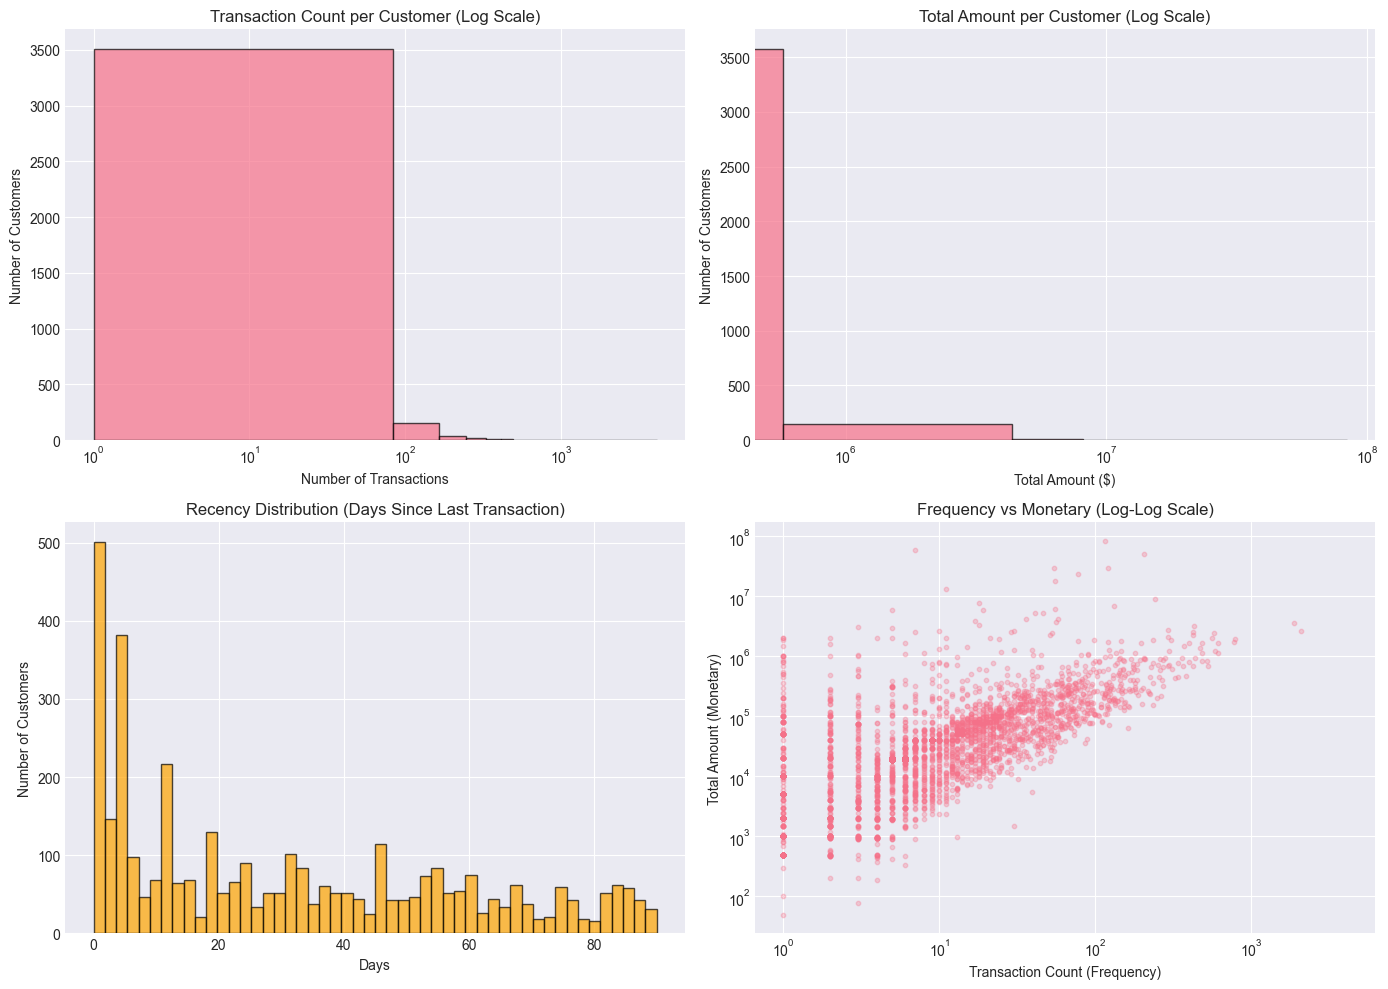

In [19]:
# Visualize customer distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Transaction count distribution (log scale)
axes[0, 0].hist(customer_stats['TransactionCount'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('Transaction Count per Customer (Log Scale)')
axes[0, 0].set_xlabel('Number of Transactions')
axes[0, 0].set_ylabel('Number of Customers')

# Total amount distribution (log scale)
axes[0, 1].hist(customer_stats['TotalAmount'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Total Amount per Customer (Log Scale)')
axes[0, 1].set_xlabel('Total Amount ($)')
axes[0, 1].set_ylabel('Number of Customers')

# Recency distribution
axes[1, 0].hist(customer_stats['RecencyDays'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Recency Distribution (Days Since Last Transaction)')
axes[1, 0].set_xlabel('Days')
axes[1, 0].set_ylabel('Number of Customers')

# Scatter: Frequency vs Monetary
axes[1, 1].scatter(customer_stats['TransactionCount'], customer_stats['TotalAmount'], alpha=0.3, s=10)
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Frequency vs Monetary (Log-Log Scale)')
axes[1, 1].set_xlabel('Transaction Count (Frequency)')
axes[1, 1].set_ylabel('Total Amount (Monetary)')

plt.tight_layout()
plt.show()

# EDA Key Insights: Credit Risk Model

## Dataset Overview

- **Total transactions:** 95,662
- **Unique customers:** 3,742
- **Unique accounts:** 3,633
- **Unique products:** 23
- **Date range:** November 15, 2018 - February 13, 2019 (approx. 3 months)
- **Currency:** UGX (Ugandan Shilling)
- **Country Code:** 256 (Uganda)
- **Missing values:** None (0% missing in all columns)

---

## Top 5 Most Important Insights for Feature Engineering

### Insight 1: Significant Customer Segmentation Opportunity (RFM Foundation)

| Aspect | Detail |
|:---|:---|
| **Finding** | Customer transaction patterns vary dramatically. Transaction count ranges from 1 to 4,091 per customer. Recency ranges from 0 to over 300 days. |
| **Implication** | RFM (Recency, Frequency, Monetary) segmentation will be highly effective for creating our proxy target variable. Customers with low Frequency, low Monetary, and high Recency are likely candidates for the "high-risk" proxy. |
| **Action** | Use K-Means clustering on RFM features to create 3 segments and identify the highest-risk group. |

---

### Insight 2: Highly Skewed Monetary Features

| Aspect | Detail |
|:---|:---|
| **Finding** | Transaction amounts and total customer spend are heavily right-skewed with extreme outliers. Mean total amount per customer is $171,738 vs median of $20,000. Amount ranges from -1,000,000 to +9,880,000. |
| **Implication** | Raw monetary values will dominate models if not transformed. Log transformation is necessary for effective clustering and modeling. |
| **Action** | Apply `log1p` transformation to all monetary features before clustering and model training. |

---

### Insight 3: Fraud is Extremely Rare (Not Our Target)

| Aspect | Detail |
|:---|:---|
| **Finding** | FraudResult has only 0.20% positive cases (193 fraud transactions out of 95,662). |
| **Implication** | Fraud is not our primary target (we are building a credit risk model, not a fraud detector). This imbalance affects how we treat FraudResult as a feature. |
| **Action** | Keep FraudResult as a potential feature but be aware of its imbalance. Do NOT use it as our proxy target for credit risk. |

---

### Insight 4: Temporal Patterns Exist

| Aspect | Detail |
|:---|:---|
| **Finding** | Transaction volume peaks during business hours. TransactionStartTime has 94,556 unique values (nearly every transaction has a unique timestamp). |
| **Implication** | Time-based features (hour, day of week, month) may be predictive of customer engagement and risk behavior. |
| **Action** | Engineer time-based features: transaction hour, day of week, weekend indicator, and time since first/last transaction. |

---

### Insight 5: Category and Channel Distributions Are Concentrated

| Aspect | Detail |
|:---|:---|
| **Finding** | ProductCategory dominated by `financial_services` (45,405) and `airtime` (45,027). ChannelId dominated by ChannelId_3 (56,935) and ChannelId_2 (37,141). PricingStrategy: 2 (79,848), 4 (13,562). |
| **Implication** | Rare categories need grouping into an 'Other' category to avoid model instability and overfitting. |
| **Action** | Group rare categories (less than 1% frequency) into an 'Other' bucket before one-hot encoding. |

---

## Additional Observations

| Observation | Implication | Action |
|:---|:---|:---|
| No missing values found in any column | Data quality is good | No imputation needed |
| Strong correlation between Amount and Value (0.99) | Redundant features | Drop Value column, keep Amount |
| Debits (positive Amount) dominate | Credits are rare events | Consider creating a credit ratio feature |
| TransactionId, BatchId are unique identifiers | No predictive value | Drop before modeling |
| Amount has 25.55% outliers by IQR method | Extreme values exist | Use log transformation, not removal |
| CountryCode and CurrencyCode have single value | No predictive value | Drop these columns |
| FraudResult correlation with Amount (0.557) and Value (0.567) | Fraud tends to occur with higher amounts | Keep as feature but note imbalance |

---

## Customer-Level Statistics Summary

| Metric | Value |
|:---|:---|
| Total customers | 3,742 |
| Mean transaction count per customer | 25.6 |
| Median transaction count per customer | 7 |
| Min transaction count per customer | 1 |
| Max transaction count per customer | 4,091 |
| Mean total amount per customer | $171,737.74 |
| Median total amount per customer | $20,000.00 |
| Mean recency (days since last transaction) | 30.5 days |
| Median recency | 24 days |

---

## Category Distributions

### ProductCategory
| Category | Count |
|:---|:---|
| financial_services | 45,405 |
| airtime | 45,027 |
| utility_bill | 1,920 |
| data_bundles | 1,613 |
| tv | 1,279 |
| ticket | 216 |
| movies | 175 |
| transport | 25 |
| other | 2 |

### ChannelId
| Channel | Count |
|:---|:---|
| ChannelId_3 | 56,935 |
| ChannelId_2 | 37,141 |
| ChannelId_5 | 1,048 |
| ChannelId_1 | 538 |

### PricingStrategy
| Strategy | Count |
|:---|:---|
| 2 | 79,848 |
| 4 | 13,562 |
| 1 | 1,867 |
| 0 | 385 |

---

## Recommended Feature Engineering Plan

### For Proxy Variable (RFM Clustering - Task 4)

1. Calculate per customer: Recency (days since last transaction)
2. Calculate per customer: Frequency (total transaction count)
3. Calculate per customer: Monetary (total transaction amount)
4. Apply `log1p` transformation to Frequency and Monetary
5. Apply K-Means clustering (k=3) with `random_state=42`
6. Label the cluster with lowest F/M and highest R as `is_high_risk`

### For Model Features (Task 3)

1. Aggregate per customer: mean, std, min, max, sum of Amount
2. Extract time features: hour, day, month, year, day_of_week from TransactionStartTime
3. Encode categorical variables with frequency/one-hot encoding
4. Group rare categories (<1%) into 'Other'
5. Drop identifiers: TransactionId, BatchId, AccountId, SubscriptionId, CustomerId (after aggregation)
6. Drop constant columns: CurrencyCode, CountryCode

---

## Correlation Summary

| Pair | Correlation |
|:---|:---|
| Amount ↔ Value | 0.990 |
| Amount ↔ FraudResult | 0.557 |
| Value ↔ FraudResult | 0.567 |

**Note:** PricingStrategy has very weak negative correlation with FraudResult (-0.034). CountryCode and CurrencyCode have no variation (single value), so correlation is NaN.

---

## Next Steps

1. **Task 3:** Implement feature engineering pipeline in `src/data_processing.py`
2. **Task 4:** Engineer RFM proxy target variable using K-Means clustering
3. **Task 5:** Train models (Logistic Regression + WoE champion, XGBoost challenger) and track with MLflow
4. **Task 6:** Deploy best model as containerized API with Docker

---
